In [0]:
%pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.6 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# 1. Data Processing 
- Environment setup and libraries
- Data loading 
- Data preview and schema inspection
- Data formatting and standardization

In addition, understand the dataset structure:
- Class column: 0 = legitimate, 1 = fraud
- Features V1-V28 are PCA-transformed (anonymized)
- Amount and Time are raw features

In [0]:
# Importing pandas and numpy for data analysis and manipulation 
import pandas as pd
import numpy as np

# Importing matplotlib for creating visualizations
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Import seaborn for statistical data visualization
import seaborn as sns

import umap

import shap 

# Handling the class imbalance
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Model selection
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# XGBoost
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import classification_report, roc_auc_score

# To suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [0]:
# Read dataset from Databricks Catalog
spark_df = spark.read.table("workspace.default.creditcard")
df = spark_df.toPandas()

# Preview the dataset and check any missing values
print("Raw data:")
display(df.head())
print("Missing data:")
print(df.isnull().sum().sum())
print("\n")

# Understnad the dataset structure
print("Data Info: ")
display(df.info())
print("\n")
print("Data Description: ")
print(df.describe())
print("\n")
df['Class'].value_counts()

Raw data:


Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0.0,-1.3598071336738,-0.0727811733098497,2.53634673796914,1.37815522427443,-0.338320769942518,0.462387777762292,0.239598554061257,0.0986979012610507,0.363786969611213,0.0907941719789316,-0.551599533260813,-0.617800855762348,-0.991389847235408,-0.311169353699879,1.46817697209427,-0.470400525259478,0.207971241929242,0.0257905801985591,0.403992960255733,0.251412098239705,-0.018306777944153,0.277837575558899,-0.110473910188767,0.0669280749146731,0.128539358273528,-0.189114843888824,0.133558376740387,-0.0210530534538215,149.62,0
0.0,1.19185711131486,0.26615071205963,0.16648011335321,0.448154078460911,0.0600176492822243,-0.0823608088155687,-0.0788029833323113,0.0851016549148104,-0.255425128109186,-0.166974414004614,1.61272666105479,1.06523531137287,0.48909501589608,-0.143772296441519,0.635558093258208,0.463917041022171,-0.114804663102346,-0.183361270123994,-0.145783041325259,-0.0690831352230203,-0.225775248033138,-0.638671952771851,0.101288021253234,-0.339846475529127,0.167170404418143,0.125894532368176,-0.00898309914322813,0.0147241691924927,2.69,0
1.0,-1.35835406159823,-1.34016307473609,1.77320934263119,0.379779593034328,-0.503198133318193,1.80049938079263,0.791460956450422,0.247675786588991,-1.51465432260583,0.207642865216696,0.624501459424895,0.066083685268831,0.717292731410831,-0.165945922763554,2.34586494901581,-2.89008319444231,1.10996937869599,-0.121359313195888,-2.26185709530414,0.524979725224404,0.247998153469754,0.771679401917229,0.909412262347719,-0.689280956490685,-0.327641833735251,-0.139096571514147,-0.0553527940384261,-0.0597518405929204,378.66,0
1.0,-0.966271711572087,-0.185226008082898,1.79299333957872,-0.863291275036453,-0.0103088796030823,1.24720316752486,0.23760893977178,0.377435874652262,-1.38702406270197,-0.0549519224713749,-0.226487263835401,0.178228225877303,0.507756869957169,-0.28792374549456,-0.631418117709045,-1.0596472454325,-0.684092786345479,1.96577500349538,-1.2326219700892,-0.208037781160366,-0.108300452035545,0.00527359678253453,-0.190320518742841,-1.17557533186321,0.647376034602038,-0.221928844458407,0.0627228487293033,0.0614576285006353,123.5,0
2.0,-1.15823309349523,0.877736754848451,1.548717846511,0.403033933955121,-0.407193377311653,0.0959214624684256,0.592940745385545,-0.270532677192282,0.817739308235294,0.753074431976354,-0.822842877946363,0.53819555014995,1.3458515932154,-1.11966983471731,0.175121130008994,-0.451449182813529,-0.237033239362776,-0.0381947870352842,0.803486924960175,0.408542360392758,-0.00943069713232919,0.79827849458971,-0.137458079619063,0.141266983824769,-0.206009587619756,0.502292224181569,0.219422229513348,0.215153147499206,69.99,0


Missing data:
0


Data Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non

Class
0    284315
1       492
Name: count, dtype: int64

# 2. EDA and Visualization 
### 2-1. Class Imbalance Visualization 
Since fraudulent transactions (Class = 1) are extremely rare, the dataset exhibits a severe class imbalance. Fraud cases account for only 0.17% of all transactions, with 492 frauds out of 284,807 records.

This imbalance has important implications for model evaluation, as accuracy alone would be misleading. Therefore, in the subsequent analysis, we apply balancing techniques to create comparable samples of legitimate and fraudulent transactions for exploratory comparison purposes.

- Check for class imbalance 

<Axes: xlabel='Class', ylabel='count'>

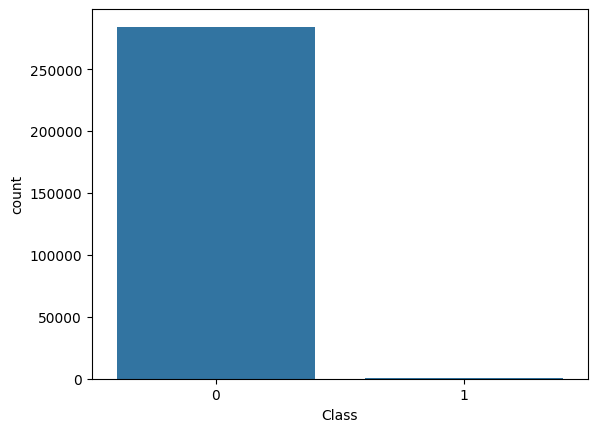

In [0]:
sns.countplot(data=df, x='Class')

### 2-2. Transaction Amounts Distribution
Using a boxplot helps compare the median, spread, and outlier between fraud and non-fraud. Fraudulent transactions sometimes have a narrower or unusual range.

In [0]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]


legit['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [0]:
fraud['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

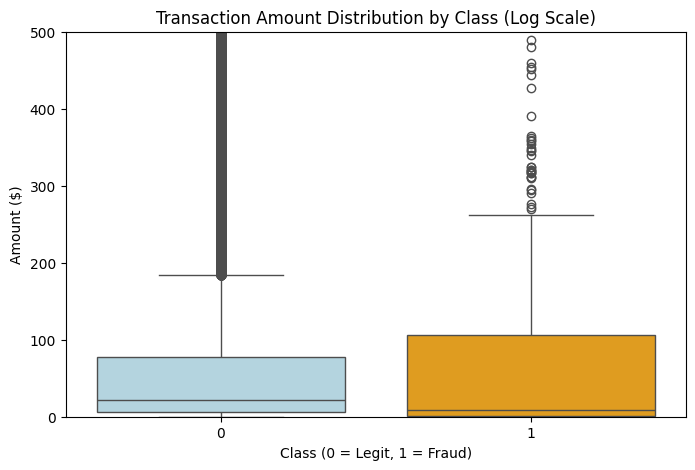

In [0]:
plt.figure(figsize=(8, 5))
color = ["lightblue", "orange"]
sns.boxplot(x='Class', y='Amount', data=df, palette=color)
plt.title("Transaction Amount Distribution by Class (Log Scale)")
plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.ylabel("Amount ($)")
plt.ylim(0, 500)  # Optional: limit y-axis to focus on most values
plt.show()

The boxplot shows that fraudulent transactions have a lower median amount than legitimate ones, indicating that fraud often involves smaller transaction values.

However, the fraud class exhibits a larger interquartile range (IQR), suggesting greater variability in transaction amounts among typical fraud cases. This indicates that fraudulent activity does not follow a single consistent amount pattern, but rather spans a wider range of transaction values compared to legitimate transactions.

The histograms display the distribution of transaction amounts.

- The data is divided into 50 intervals along the x-axis. (bins=50)
- The y-axis represents the number of transactions that fall within each amount/time range.

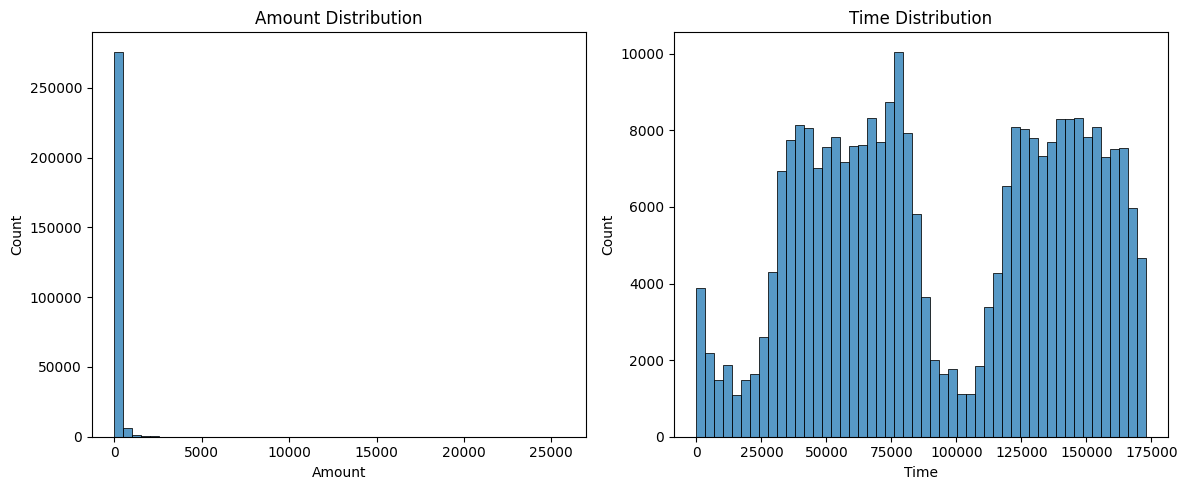

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

sns.histplot(df['Amount'], bins=50, ax=axes[0])
axes[0].set_title('Amount Distribution')

sns.histplot(df['Time'], bins=50, ax=axes[1])
axes[1].set_title('Time Distribution')

plt.tight_layout()
plt.show()

The histogram illustrates the time elapsed since the first transaction, measured in seconds.

- This is useful for identifying when transactions occur and whether fraudulent activity is more common during certain times of the day.

The distribution of transaction amounts separately for fraudulent and legitimate transactions.

The output explanation for Amount column:

- count 284315.000000 → Total number of transactions analyzed
- mean 88.291022 → Average transaction amount ≈ 88.29
- std 250.105092 → Standard deviation: lots of variation
- min 0.000000 → Smallest transaction was 0.00
- 25% 5.650000 → 25% of transactions were less than 5.65
- 50% 22.000000 → Median amount = 22.00
- 75% 77.050000 → 75% were less than 77.05
- max 25691.160000 → Largest transaction = $25,691.16



Using a histogram shows the frequency distribution of transaction amounts clearly. The fraud cases cluster at specific values, like under $100 or around even dollar amounts

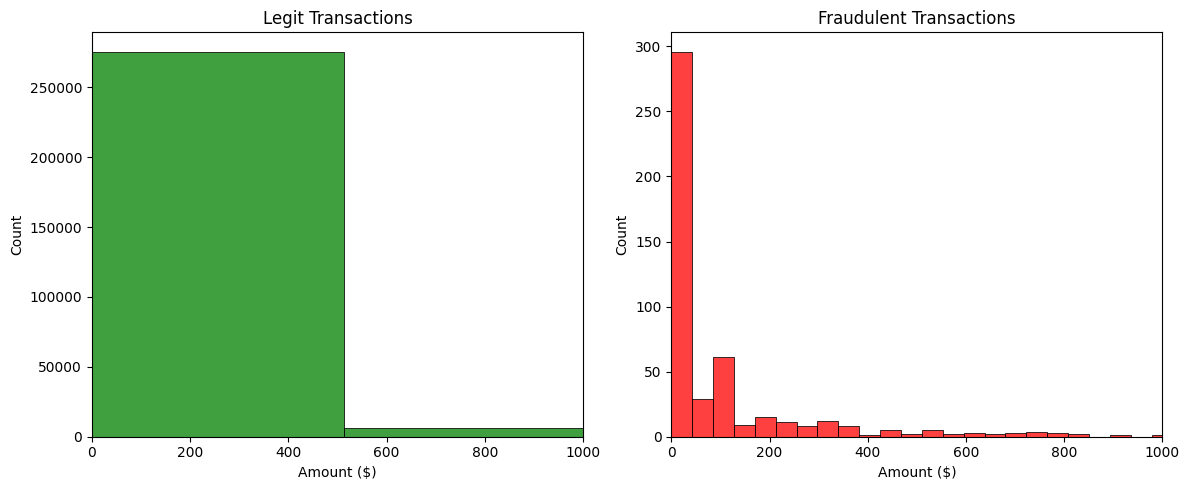

In [0]:
plt.figure(figsize=(12, 5))

# Legitimate transactions
plt.subplot(1, 2, 1)
sns.histplot(legit['Amount'], bins=50, color='green')
plt.title("Legit Transactions")
plt.xlabel("Amount ($)")
plt.ylabel("Count")
plt.xlim(0, 1000)  # Optional: focus on normal range

# Fraudulent transactions
plt.subplot(1, 2, 2)
sns.histplot(fraud['Amount'], bins=50, color='red')
plt.title("Fraudulent Transactions")
plt.xlabel("Amount ($)")
plt.ylabel("Count")
plt.xlim(0, 1000)

plt.tight_layout()
plt.show()

Key insights
- Most legitimate transactions are small (median = $22), but there's a long tail — some are very large.

- The high standard deviation and large max show that the distribution is right-skewed — meaning most transactions are small, but a few big ones pull the average up.

### 2-3. Time-Based Transaction Patterns
2-3-1. Transaction Frequency Over Time

When visualized using density-based distributions, fraudulent transactions exhibit a more uneven temporal distribution, with higher relative density concentrated in specific time windows. In contrast, legitimate transactions display a more uniform temporal density across the observation period.

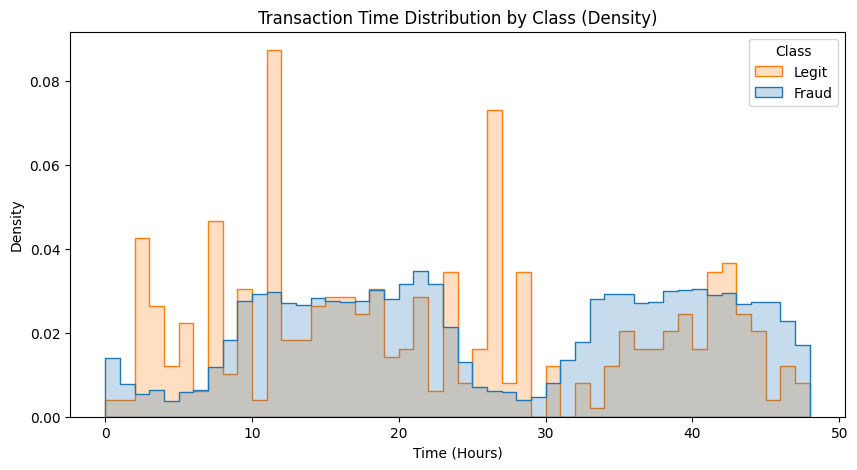

In [0]:
# Convert seconds to hours
df['Hour'] = df['Time'] / 3600

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Hour',
    hue='Class',
    bins=48,
    stat='density',
    common_norm=False,
    element='step'
)

plt.xlabel("Time (Hours)")
plt.ylabel("Density")
plt.title("Transaction Time Distribution by Class (Density)")
plt.legend(title="Class", labels=["Legit", "Fraud"])
plt.show()


2-3-2. Fraud Ratio Over Time

Certain time windows exhibit elevated fraud ratios, suggesting that fraudulent activity is more concentrated during specific periods rather than occurring uniformly over time.

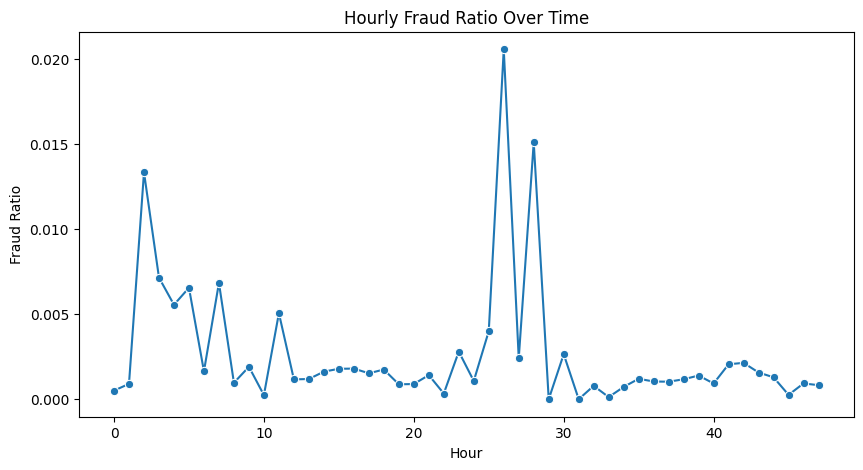

In [0]:
# Create hourly bins
df['Hour_bin'] = df['Hour'].astype(int)

# Calculate fraud ratio per hour
hourly_stats = (
    df.groupby('Hour_bin')['Class']
      .agg(['count', 'sum'])
      .reset_index()
)

hourly_stats['fraud_ratio'] = hourly_stats['sum'] / hourly_stats['count']

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly_stats,
    x='Hour_bin',
    y='fraud_ratio',
    marker='o'
)

plt.xlabel("Hour")
plt.ylabel("Fraud Ratio")
plt.title("Hourly Fraud Ratio Over Time")
plt.show()


2-3-3. Time Gap Between Transactions

Fraudulent transactions tend to occur in shorter time intervals, indicating burst-like activity patterns compared to legitimate transactions.

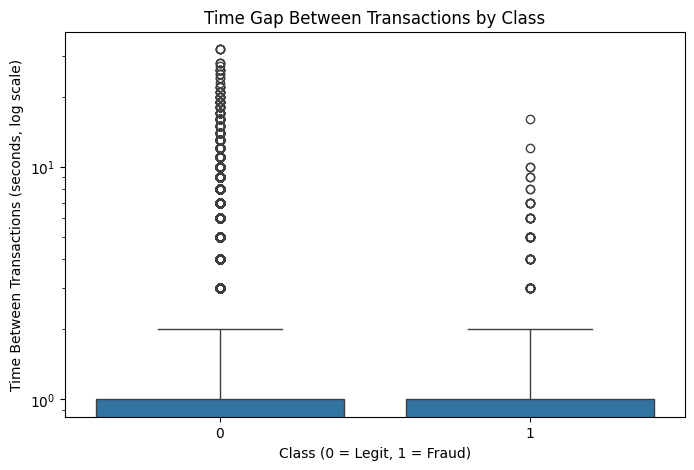

In [0]:
# Sort by time
df_sorted = df.sort_values('Time')

# Compute time difference between consecutive transactions
df_sorted['time_diff'] = df_sorted['Time'].diff()

plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Class',
    y='time_diff',
    data=df_sorted
)

plt.yscale('log')
plt.xlabel("Class (0 = Legit, 1 = Fraud)")
plt.ylabel("Time Between Transactions (seconds, log scale)")
plt.title("Time Gap Between Transactions by Class")
plt.show()


### 2-4. Feature Distribution Analysis (V1–V28)
2-4-0. Selection of Strong Features via Pearson Correlation

Using the Pearson correlation between all numeric features and the target variable (Class), sorts them by absolute strength, and selects the top 5 features most strongly associated with fraudulent transactions. These features are then used for detailed distributional and multivariate analysis.

In [0]:
# Compute correlation with Class
corr = df.corr(numeric_only=True)['Class'].sort_values(key=abs, ascending=False)

# Remove Class itself
corr_features = corr.drop('Class')

# Select top features
top_features = corr_features.head(5)
top_features


V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

2-4-1 Selected Feature Distributions

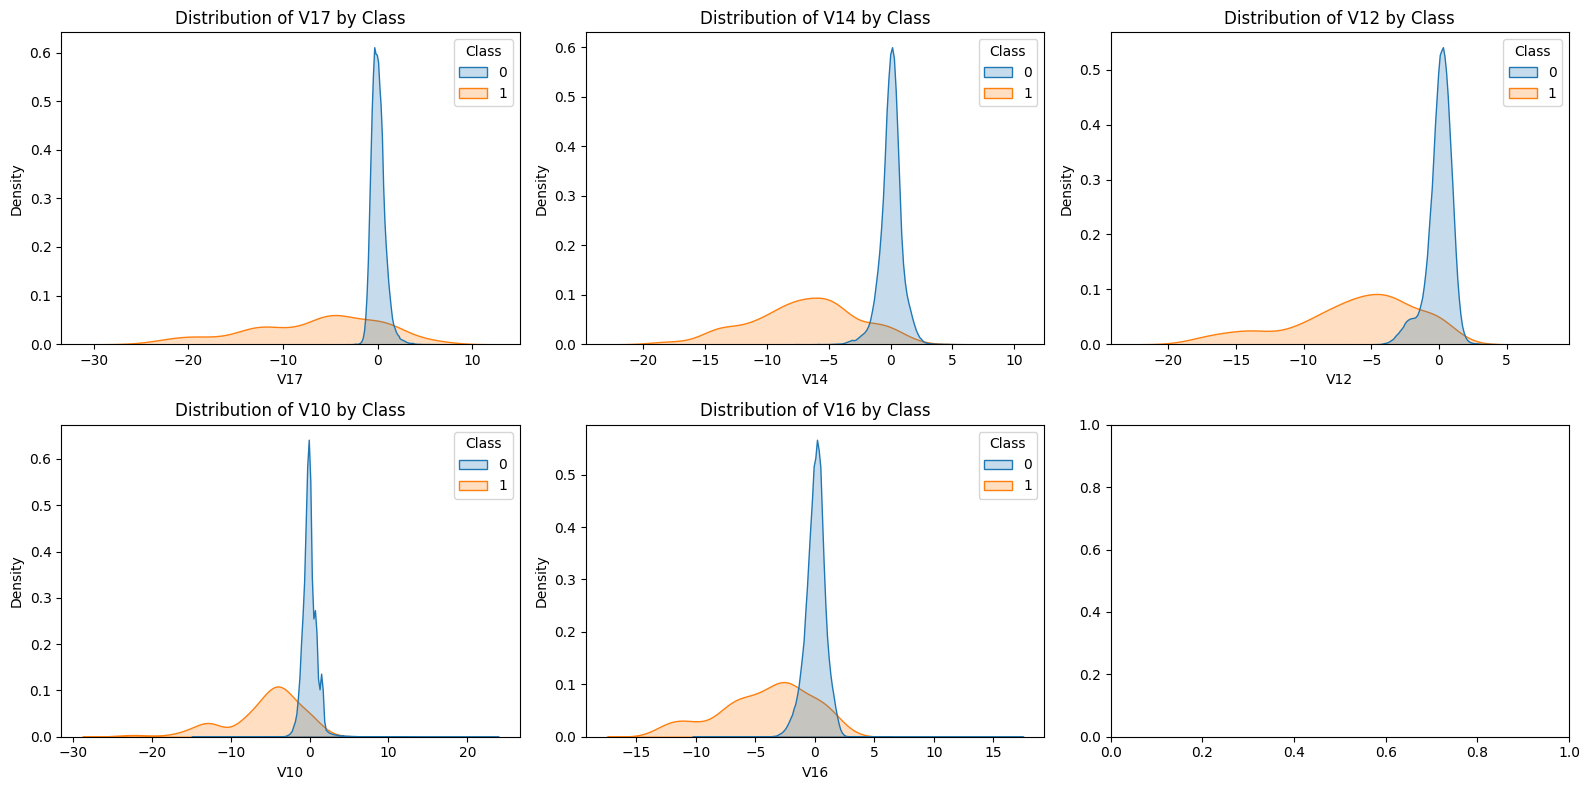

In [0]:
features = top_features.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(
        data=df,
        x=feature,
        hue='Class',
        common_norm=False,
        fill=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {feature} by Class")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()


2-4-2 Correlation Analysis

Correlation analysis highlights a subset of features that are strongly associated with fraudulent transactions, supporting the use of feature-based classification models.

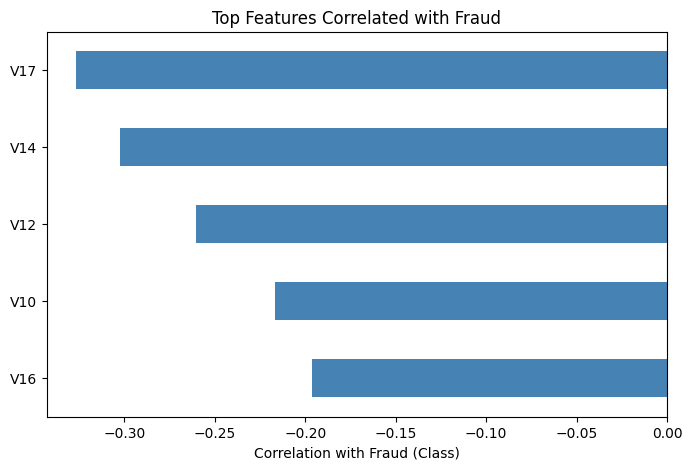

In [0]:
plt.figure(figsize=(8, 5))

top_features.plot(
    kind='barh',
    color='steelblue'
)

plt.xlabel("Correlation with Fraud (Class)")
plt.title("Top Features Correlated with Fraud")
plt.gca().invert_yaxis()
plt.show()


2-4-3. Multivariate Insight

Legitimate transactions (Class 0) tend to fall within a relatively narrow feature range, exhibiting small variations and consistent behavioral patterns. In contrast, fraudulent transactions (Class 1) are more dispersed across the feature space, with some observations lying at extreme values. This deviation from typical patterns highlights anomalous behavior that can be exploited as a predictive signal in classification models.

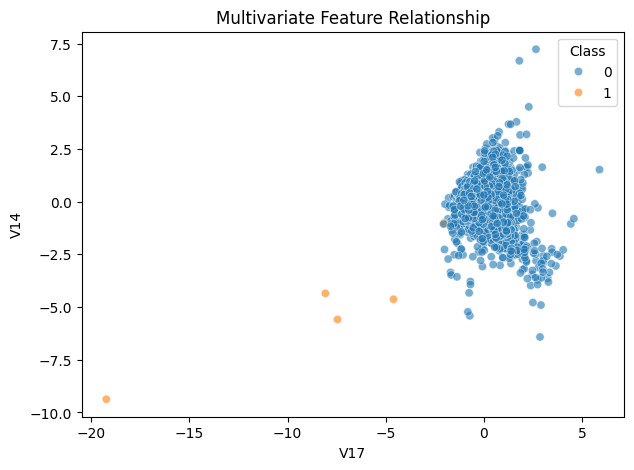

In [0]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=sample_df,
    x=top_features.index[0],
    y=top_features.index[1],
    hue='Class',
    alpha=0.6
)

plt.title("Multivariate Feature Relationship")
plt.show()


2-4-4. Non-linear Feature Structure Visualization (UMAP)

UMAP was applied to project high-dimensional transaction features into a two-dimensional space. Legitimate transactions form a dense and compact cluster, while fraudulent transactions appear more scattered and partially separated. This suggests that fraud cases deviate from normal transaction patterns across multiple features, providing useful signals for downstream classification models.

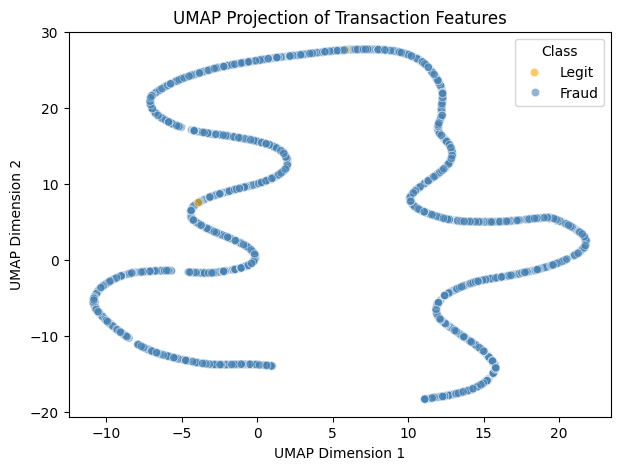

In [0]:
# Only numerical features are considered (excluding Class).
features = df.drop(columns=['Class'])

# Sampling (for visualization only)
X_umap = features.sample(5000, random_state=42)
y_umap = df.loc[X_umap.index, 'Class']

# Building up the UMAP model
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

# Dimensionality reduction
embedding = reducer.fit_transform(X_umap)

# Plotting
plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=y_umap,
    alpha=0.6,
    palette={0: "steelblue", 1: "orange"}
)

plt.title("UMAP Projection of Transaction Features")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Class", labels=["Legit", "Fraud"])
plt.show()

### 2-5. Summary of EDA Findings

Exploratory data analysis reveals that the dataset is extremely imbalanced, with fraudulent transactions accounting for only 0.17% of all records. Transaction amount analysis shows that fraud cases tend to involve smaller amounts, with occasional extreme values, distinguishing them from legitimate transactions.

Time-based analysis indicates that fraudulent transactions are unevenly distributed over the observation period, exhibiting localized temporal patterns rather than a uniform distribution.

Feature distribution and correlation analysis identify several variables (e.g., V14, V17) that exhibit strong associations with fraudulent activity. Multivariate visualization further shows that legitimate transactions cluster within a narrow feature range, while fraud cases are more dispersed and often lie outside typical regions.

Overall, these findings suggest that fraudulent behavior deviates from normal transaction patterns and provides exploitable signals for classification models.

# 3. Modeling Preparation and Strategy
### 3-1. Problem Definition & Evaluation Metrics
The goal is to identify transactions (Class = 1) from legitimate ones (Class = 0). Given the dataset's severe class imbalance, accuracy alone is insufficient. Therefore, evaluation focuses on metrics such as precision, recall, F1-score, and ROC-AUC to ensure that fraudulent transactions are correctly detected.

### 3-2. Data Preparation
3-2-1. Handling imbalance

The dataset exhibits extreme class imbalance, with fraudulent transactions representing only 0.17% of all records. To prevent the model from being biased toward the majority class, we applied oversampling of the minority class (SMOTE) and/or used class-weight adjustments in tree-based models. This ensures that the classifier gives sufficient attention to the rare fraudulent cases while training.

In [0]:
X = df[top_features.index]
y = df['Class']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE oversampling
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

3-2-2. Feature Selection & Scaling

Based on the EDA, we selected the top features that show the strongest correlation with the target variable (Class). These features capture meaningful distributional differences between fraudulent and legitimate transactions.
For linear models, features were standardized to have zero mean and unit variance, whereas tree-based models were trained on raw features, as they are insensitive to feature scaling.

In [0]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


### 3-3. Model Selection (Random Forest vs. Logistic Regression vs. XGBoost)

We evaluated several classification algorithms suitable for imbalanced datasets.

- Random Forest and XGBoost were chosen as tree-based models capable of capturing non-linear relationships and complex interactions.
- Logistic Regression was included as a baseline linear model for comparison.

Class weights were adjusted to balance the contribution of minority class samples, which improves the model’s ability to detect fraudulent transactions.

In [0]:
# Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [0]:
# XGBoost

# Calculate the proportion between Class 0 and Class 1
count_0 = (y_train == 0).sum()
count_1 = (y_train == 1).sum()

scale_pos_weight = count_0 / count_1
print("scale_pos_weight =", scale_pos_weight)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train_res, y_train_res)

scale_pos_weight = 577.2868020304569


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [0]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### 3-4. Model Evaluation

Models were evaluated on a held-out test set using metrics appropriate for highly imbalanced data. Since accuracy can be misleading due to the low prevalence of fraud, the following metrics were emphasized:
- Recall: the proportion of fraudulent transactions correctly identified
- Precision: the proportion of predicted fraud cases that are truly fraudulent
- F1-score: the harmonic mean of precision and recall
- ROC-AUC: overall separability between legitimate and fraudulent classes

Confusion matrices, ROC curves, and Precision–Recall (PR) curves were used to assess model performance. While ROC curves provide a general measure of a model’s discriminative ability, PR curves are more informative in highly imbalanced settings, as they focus on the trade-off between precision and recall for the minority (fraud) class. This evaluation framework enables a more realistic assessment of both fraud detection capability and prediction reliability.

3-4-1. Precision–Recall Curve Analysis

Given the extreme class imbalance, the Precision–Recall (PR) curve provides a more informative evaluation than ROC-AUC.

The PR curve highlights the trade-off between detecting fraudulent transactions (recall) and minimizing false alarms (precision).

A high ROC-AUC may still correspond to poor precision for the minority class, making PR analysis critical for fraud detection tasks.

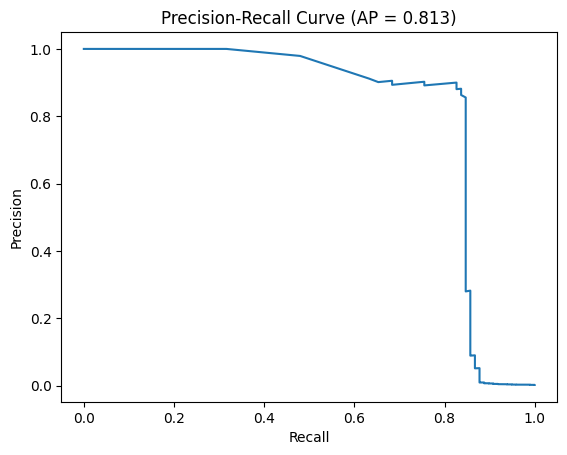

In [0]:
y_prob = model.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap:.3f})")
plt.show()

The Precision–Recall curve yields an Average Precision (AP) score of 0.813, indicating strong performance in identifying fraudulent transactions under severe class imbalance. Since AP summarizes precision across all recall levels, this result suggests that the model maintains high prediction reliability even as recall increases. Compared to the extremely low baseline precision determined by fraud prevalence, the achieved AP demonstrates substantial improvement over random guessing and highlights the model’s effectiveness in practical fraud detection.

3-4-2. Cost-based Evaluation (Business Perspective)

To reflect real-world impact, we introduced a cost-sensitive evaluation assuming a false negative cost of $500 and a false positive cost of $5.

This analysis demonstrates that models with higher recall for fraud can significantly reduce overall financial loss, even at the expense of lower precision.

In [0]:
FN_COST = 500
FP_COST = 5

models = {
    'Random Forest': clf,
    'Logistic Regression': lr,
    'XGBoost': xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Cost-based evaluation
    total_cost = fn * FN_COST + fp * FP_COST

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print(f"False Negatives (FN): {fn}")
    print(f"False Positives (FP): {fp}")
    print(f"Total Cost: ${total_cost:,}")
    print()


--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.47      0.85      0.61        98

    accuracy                           1.00     56962
   macro avg       0.74      0.92      0.80     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9510560643081093
False Negatives (FN): 15
False Positives (FP): 93
Total Cost: $7,965

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.90      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9683494740045708
False Negatives (FN): 10
False Positives (FP): 1308
Total Cost: $11,540

--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00   

Among the three evaluated models, Random Forest achieved the best balance between recall (0.85) and precision (0.47) for fraud detection, successfully identifying most fraudulent transactions while limiting false positives.

Logistic Regression and XGBoost achieved slightly higher recall (0.90 and 0.88, respectively), but their extremely low precision led to a large number of false positives, substantially increasing operational cost.

When incorporating cost-based evaluation, Random Forest resulted in the lowest total cost, despite not having the highest ROC-AUC. This indicates that Random Forest provides the most practical and cost-effective performance for fraud detection in this highly imbalanced dataset.

### 3-5. Insights from Modeling

Confusion matrix analysis provides insight into the types of errors made by each model. In fraud detection, false negatives represent missed fraudulent transactions with direct financial loss, while false positives incur operational costs due to unnecessary transaction reviews.

Among the evaluated models, Logistic Regression and XGBoost demonstrated strong overall separability and high recall; however, their extremely low precision resulted in a large number of false positives, significantly increasing operational cost and limiting practical usability. In contrast, Random Forest achieved the lowest total cost by maintaining high fraud recall while limiting false positives, making it the most practical model for deployment.

These results are consistent with EDA findings, confirming that fraudulent transactions tend to deviate from typical feature ranges rather than follow simple linear patterns. Consequently, non-linear, tree-based models are better suited to capture these complex behaviors.

Overall, these insights emphasize the importance of balancing recall and precision, leveraging EDA-driven feature understanding, and incorporating cost-based evaluation to guide practical model selection in real-world fraud detection.

# 4. Model Explainability (SHAP)
While predictive performance is critical in fraud detection, model transparency is equally important for trust, regulatory compliance, and human-in-the-loop decision making. Therefore, SHAP was applied to interpret the predictions of the selected Random Forest model at both global and transaction levels.

### 4-1. Motivation for Model Interpretability
Although predictive performance is critical in fraud detection, model interpretability is equally important for trust, regulatory compliance, and operational decision-making. Fraud detection systems are often used in high-stakes environments where incorrect predictions may lead to financial loss or poor customer experience. Therefore, understanding which features drive model predictions is essential before deployment.

### 4-2. Global Feature Importance (SHAP Summary)




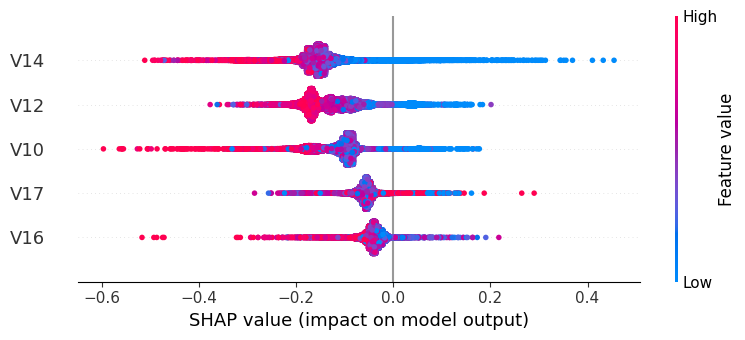

In [0]:
# Create a TreeExplainer 
explainer = shap.TreeExplainer(clf)

# Compute SHAP values (only the test set)
shap_values = explainer.shap_values(X_test)

# Plot
shap.summary_plot(
  shap_values[:, :, 1], # fraud class
  X_test,
  show=True
)

From the SHAP summary plot, the top features influencing fraud prediction are V14, V12, V10, V17, and V16.

Most high feature values (red points) have negative SHAP values, indicating they decrease the predicted fraud probability, whereas most low feature values (blue points) have positive SHAP values, indicating they increase the predicted fraud probability.

This suggests that, for these features, transactions with unusually low values are more likely to be classified as fraud by the model, while high values are associated with normal transactions.

### 4-3. Transaction-level Explanation (Single Case SHAP)


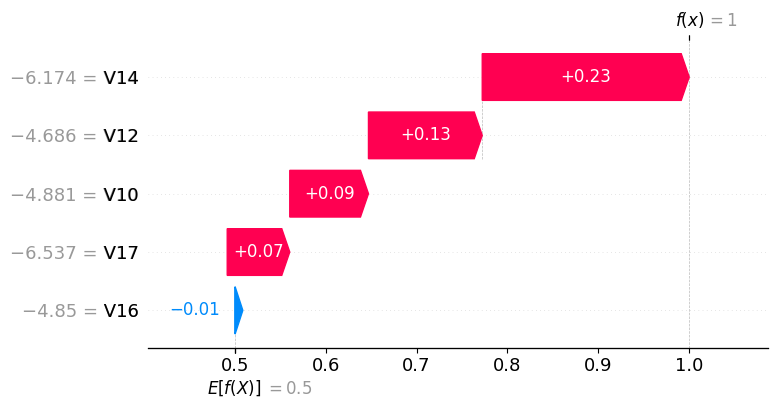

In [0]:
# Pick the highest predicted fraud probability
y_prob = clf.predict_proba(X_test)[:, 1]
fraud_idx = np.argmax(y_prob)
fraud_instance = X_test.iloc[[fraud_idx]]

# Compute SHAP values (The latest SHAP)
shap_values = explainer(fraud_instance)  # <- new API, returns Explanation object

# For binary classifier, pick positive/fraud class
# shap_values.values has shape (n_samples, n_features, n_classes)
if shap_values.values.ndim == 3:
    values_1d = shap_values.values[0, :, 1]  # pick first instance, class=1
elif shap_values.values.ndim == 2:
    values_1d = shap_values.values[0]        # already single output
else:
    raise ValueError("Unsupported SHAP values shape")

# Base value (scalar)
base_value = shap_values.base_values
if isinstance(base_value, (np.ndarray, list)):
    base_value = np.array(base_value).flatten()[0]

# Waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=values_1d,
        base_values=base_value,
        data=fraud_instance.iloc[0].values,
        feature_names=fraud_instance.columns.tolist()
    )
)


In the SHAP waterfall plot for this single transaction, V14, V12, V10, and V17 contribute positively to the predicted fraud probability, with SHAP values of 0.23, 0.13, 0.09, and 0.07, respectively. V16 has a slight negative contribution of -0.01, indicating it slightly reduces the fraud probability. Overall, the model classifies this transaction as high-risk primarily due to the strong positive contributions from V14, V12, V10, and V17.

### 4-4. Consistency with EDA Findings
The SHAP analysis reinforces insights obtained from the EDA. Features identified as highly discriminative during exploratory analysis also exhibit strong contributions in the trained Random Forest model. This consistency increases confidence that the model is learning meaningful behavioral patterns rather than spurious correlations.

The feature ranking based on SHAP values differs from the simple correlation analysis because correlation measures only the linear relationship between each feature and the target, independently of other features. SHAP, on the other hand, captures the contribution of each feature within the trained Random Forest model, accounting for non-linear interactions and dependencies among features. As a result, some features with moderate correlation, such as V14, may appear more important to the model than features with higher linear correlation, such as V17.

This observation also aligns with the non-linear structures revealed by UMAP and multivariate scatter plots in the EDA, further confirming that the Random Forest model effectively captures complex feature patterns.
